In [92]:
import numpy as np
import pandas as pd

In [93]:
df = pd.read_csv("/home/junix/sms-spam-classifier/spam.csv", encoding="latin-1")
print(df)

        v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


In [94]:
df.shape

(5572, 5)

In [95]:
# 1. cleeaning the data
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Model Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [97]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [98]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [99]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)
df.sample(8)

,target,text
2006,ham,Shopping lor. Them raining mah hard 2 leave or...
3179,ham,There the size of elephant tablets & u shove u...
931,ham,Congratulations ore mo owo re wa. Enjoy it and...
2883,ham,Cbe is really good nowadays:)lot of shop and s...
1450,ham,Msg me when rajini comes.
3327,ham,No we put party 7 days a week and study lightl...
3806,ham,Pls dont restrict her from eating anythin she ...
3739,ham,No da. . Vijay going to talk in jaya tv


In [100]:
# df["target"] = df["target"].map({"ham": "0", "spam": "1"})
# df.sample(10)

In [101]:
# df["target"] = (df["target"] == "ham").astype(int)
# df.head()

In [102]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["target"])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [103]:
#checking for missing and duplicate values
print(df.isnull().sum())


target    0
text      0
dtype: int64


In [104]:
print(df.duplicated().sum())

403


In [105]:
df = df.drop_duplicates(keep="first")
print(df.duplicated().sum())

0


In [106]:
df.shape

(5169, 2)

In [107]:
df.value_counts()

target  text                                                                                                                                                                          
0        &lt;#&gt;  in mca. But not conform.                                                                                                                                              1
         &lt;#&gt;  mins but i had to stop somewhere first.                                                                                                                               1
         &lt;DECIMAL&gt; m but its not a common car here so its better to buy from china or asia. Or if i find it less expensive. I.ll holla                                              1
         and  picking them up from various points                                                                                                                                         1
         came to look at the flat, seems ok, in his 50s? * Is awa

In [108]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

([<matplotlib.patches.Wedge at 0x7fb8966bae90>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

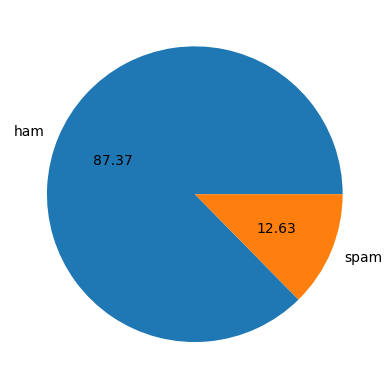

In [110]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
#autopct is used to show the percentage of each class in the pie chart and %0.2f is used to format the percentage to 2 decimal places

In [111]:
#notice rhat the data is imbalanced!

In [112]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [113]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /home/junix/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [114]:
#adding a new column for the number of characters in the text message
df["num_characters"] = df["text"].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [115]:
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))
df["num_sentences"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()   

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   target          5169 non-null   int64 
 1   text            5169 non-null   object
 2   num_characters  5169 non-null   int64 
 3   num_words       5169 non-null   int64 
 4   num_sentences   5169 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 242.3+ KB


In [117]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [118]:
df[df['target'] == '1'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


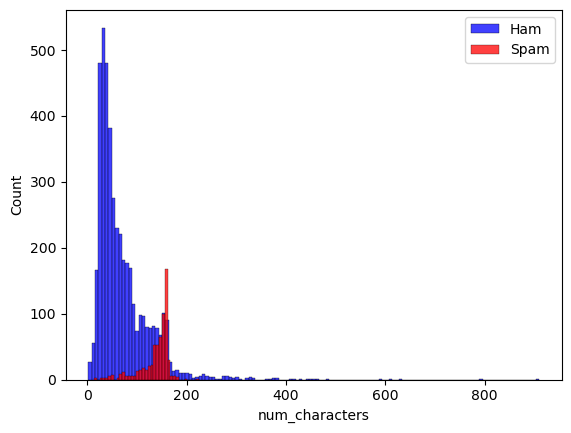

In [119]:
sns.histplot(df[df['target'] == 0]['num_characters'], color = 'blue', label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], color = 'red', label='Spam')
plt.legend()

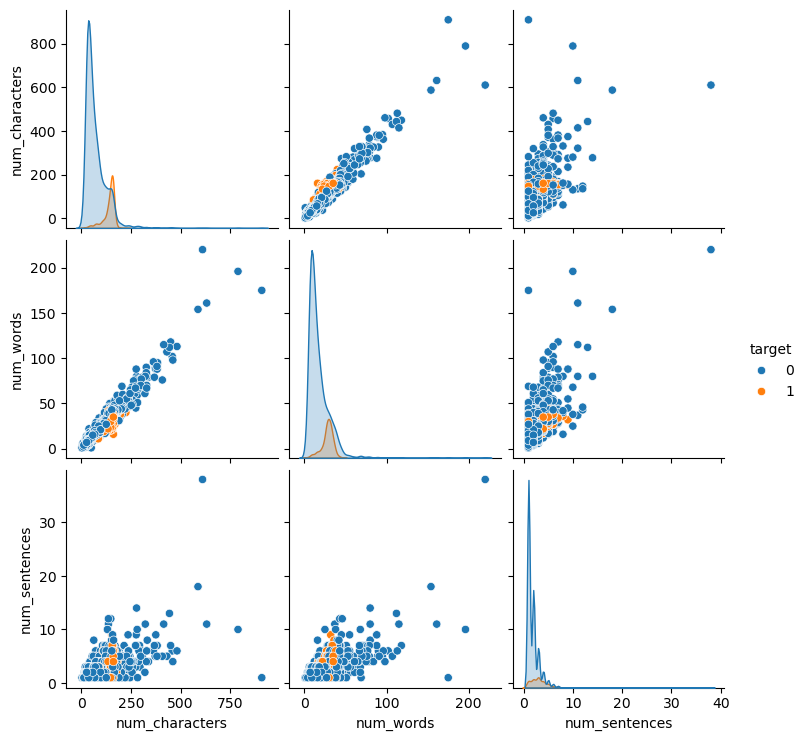

In [120]:
sns.pairplot(df, hue='target')

<Axes: >

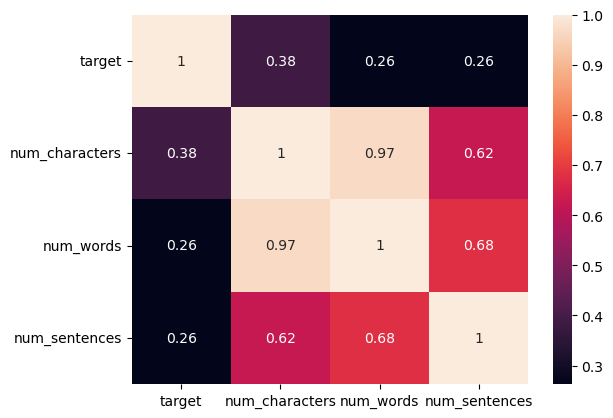

In [121]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [122]:
#text preprocessing

In [123]:
def text_preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        y.append(lemmatizer.lemmatize(i))

    return " ".join(y)

In [124]:
from nltk.corpus import stopwords
import string


In [125]:
text_preprocessing("????????????????????If you're visiting this page, you're likely here because you're")

'visiting page likely'

In [126]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [127]:
df['transformed_text'] = df['text'].apply(text_preprocessing)

In [128]:
df.sample(7)

,target,text,num_characters,num_words,num_sentences,transformed_text
3086,0,So i asked how's anthony. Dad. And your bf,42,12,3,asked anthony dad bf
3446,0,Sitting ard nothing to do lor. U leh busy w work?,49,13,2,sitting ard nothing lor u leh busy w work
2824,1,Congratulations - Thanks to a good friend U ha...,158,31,4,congratulation thanks good friend u xmas prize...
3299,0,Just do what ever is easier for you,35,8,1,ever easier
1946,0,Hey we can go jazz power yoga hip hop kb and y...,54,12,1,hey go jazz power yoga hip hop kb yogasana
1704,0,What can i do? Might accidant tookplace betwee...,126,27,4,might accidant tookplace somewhere ghodbandar ...
2397,0,Neshanth..tel me who r u?,25,8,1,neshanth tel r u


In [129]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [130]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# spam_text = df.loc[df['target'] == 1, 'transformed_text'].fillna('').astype(str).str.cat(sep=' ')....when transformed text was a list of words instead of a string
spam_text = df.loc[df['target'] == 1, 'transformed_text'].str.cat(sep=' ')
spam_wc = wc.generate(spam_text)

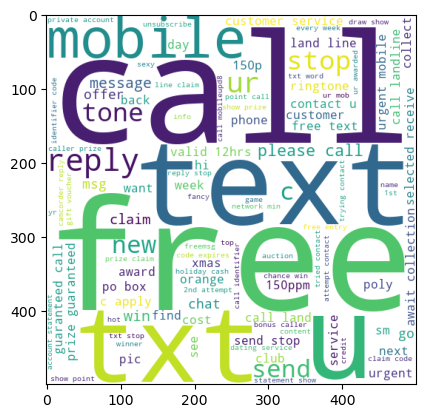

In [146]:
plt.imshow(spam_wc)

In [148]:
ham_text = df.loc[df['target'] == 0, 'transformed_text'].fillna('').astype(str).str.cat(sep=' ')
ham_wc = wc.generate(ham_text)

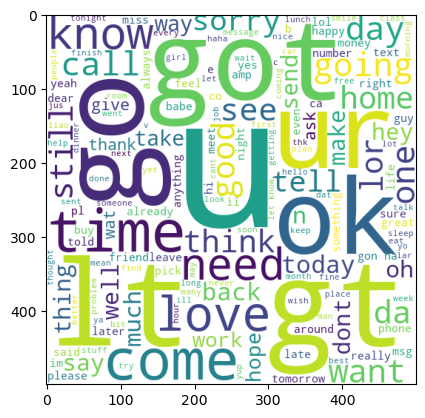

In [149]:
plt.imshow(ham_wc)

In [135]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg:
        spam_corpus.append(word)

In [136]:
len(spam_corpus)

59414

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, ' '),
  Text(1, 0, 'e'),
  Text(2, 0, 't'),
  Text(3, 0, 'a'),
  Text(4, 0, 'r'),
  Text(5, 0, 'o'),
  Text(6, 0, 'n'),
  Text(7, 0, 'l'),
  Text(8, 0, 'i'),
  Text(9, 0, 'c'),
  Text(10, 0, 's'),
  Text(11, 0, '0'),
  Text(12, 0, 'p'),
  Text(13, 0, 'd'),
  Text(14, 0, 'm'),
  Text(15, 0, 'u'),
  Text(16, 0, 'g'),
  Text(17, 0, 'y'),
  Text(18, 0, '2'),
  Text(19, 0, 'h'),
  Text(20, 0, '1'),
  Text(21, 0, '8'),
  Text(22, 0, 'w'),
  Text(23, 0, 'b'),
  Text(24, 0, 'x'),
  Text(25, 0, 'f'),
  Text(26, 0, 'k'),
  Text(27, 0, '5'),
  Text(28, 0, '7'),
  Text(29, 0, 'v')])

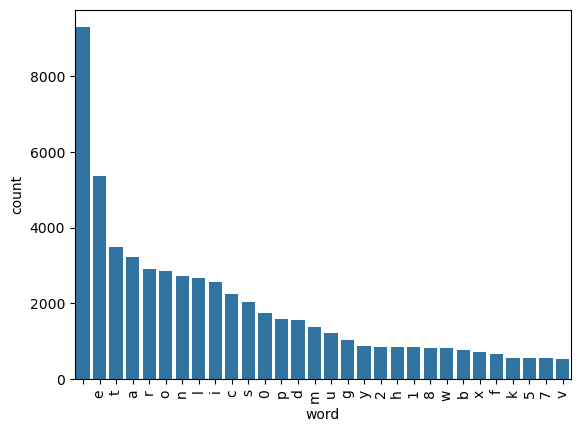

In [137]:
from collections import Counter
counter_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=counter_df, x='word', y='count')
plt.xticks(rotation='vertical')

In [138]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg:
        ham_corpus.append(word)

In [139]:
len(ham_corpus)

189501

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, ' '),
  Text(1, 0, 'e'),
  Text(2, 0, 'a'),
  Text(3, 0, 't'),
  Text(4, 0, 'o'),
  Text(5, 0, 'n'),
  Text(6, 0, 'i'),
  Text(7, 0, 'l'),
  Text(8, 0, 'r'),
  Text(9, 0, 's'),
  Text(10, 0, 'g'),
  Text(11, 0, 'd'),
  Text(12, 0, 'h'),
  Text(13, 0, 'u'),
  Text(14, 0, 'm'),
  Text(15, 0, 'c'),
  Text(16, 0, 'y'),
  Text(17, 0, 'p'),
  Text(18, 0, 'k'),
  Text(19, 0, 'w'),
  Text(20, 0, 'b'),
  Text(21, 0, 'f'),
  Text(22, 0, 'v'),
  Text(23, 0, 'x'),
  Text(24, 0, 'j'),
  Text(25, 0, '2'),
  Text(26, 0, 'z'),
  Text(27, 0, '4'),
  Text(28, 0, 'q'),
  Text(29, 0, '1')])

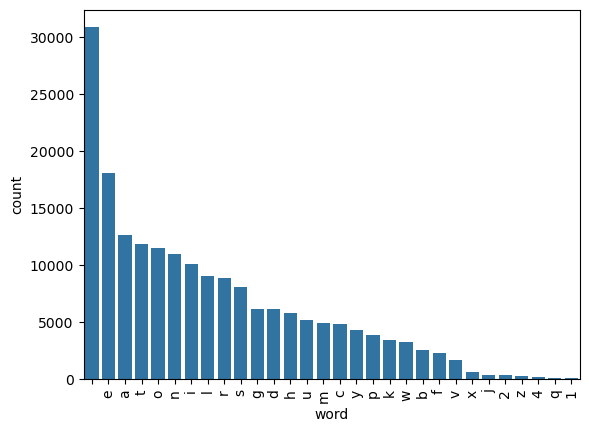

In [140]:
from collections import Counter
counter_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=counter_df, x='word', y='count')
plt.xticks(rotation='vertical')

In [141]:
#Model Building

In [142]:
#1. Naive Bayes

In [170]:
from sklearn.feature_extraction.text import CountVectorizer #Bag of Words 
cv = CountVectorizer()
from sklearn.feature_extraction.text import TfidfVectorizer #TF-IDF
tfidf = TfidfVectorizer()


In [171]:
X = cv.fit_transform(df['transformed_text']).toarray()
X1 = tfidf.fit_transform(df['transformed_text']).toarray()

In [172]:
print(X)
print(X1)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [154]:
X.shape

(5169, 7493)

In [156]:
y = df['target'].values

In [157]:
from sklearn.model_selection import train_test_split

In [173]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size=0.2, random_state=2)

In [164]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

In [165]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [167]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
# print(classification_report(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8945841392649904
[[807  89]
 [ 20 118]]
0.5700483091787439


In [168]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9632495164410058
[[870  26]
 [ 12 126]]
0.8289473684210527


In [169]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9690522243713733
[[893   3]
 [ 29 109]]
0.9732142857142857


In [174]:
bnb.fit(X_train1, y_train1)
y_pred31 = bnb.predict(X_test1)
print(accuracy_score(y_test1, y_pred31))
print(confusion_matrix(y_test1, y_pred31))
print(precision_score(y_test1, y_pred31))

0.9690522243713733
[[893   3]
 [ 29 109]]
0.9732142857142857


In [177]:
gnb.fit(X_train1, y_train1)
y_pred11 = gnb.predict(X_test1)
print(accuracy_score(y_test1, y_pred11))
print(confusion_matrix(y_test1, y_pred11))
print(precision_score(y_test1, y_pred11))

0.8887814313346228
[[807  89]
 [ 26 112]]
0.5572139303482587


In [178]:
mnb.fit(X_train1, y_train1)
y_pred21 = mnb.predict(X_test1)
print(accuracy_score(y_test1, y_pred21))
print(confusion_matrix(y_test1, y_pred21))
print(precision_score(y_test1, y_pred21))

0.9535783365570599
[[896   0]
 [ 48  90]]
1.0


In [179]:
#we use tfidf vectorizer for the model building because it gives better results than the bag of words model.with multinomial naive bayes algorithm.